# EfficientSAM — Segmentación con prompts de YOLOv9

Pipeline:
1. YOLOv9 detecta `rubber_strip` y `cut_edge` → bounding boxes
2. EfficientSAM recibe esas bboxes como prompts → máscaras pixel a pixel
3. Visualización y métricas IoU

## 1. Instalación

In [ ]:
%pip install git+https://github.com/yformer/EfficientSAM.git --quiet
%pip install ultralytics --quiet
print('Instalación OK')

## 2. Cargar modelos

In [10]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# --- YOLOv9 ---
YOLO_WEIGHTS = "runs/data/runs/michelin_v1-2/weights/best.pt"
yolo = YOLO(YOLO_WEIGHTS)
CLASS_NAMES = {0: "cut_edge", 1: "qr_code", 2: "rubber_strip"}

# --- EfficientSAM (ViT-Tiny) con pesos preentrenados ---
# Descarga manual: https://github.com/yformer/EfficientSAM/blob/main/weights/efficient_sam_vitt.pt
# Guarda el archivo en la misma carpeta que este notebook
WEIGHTS_PATH = Path("efficient_sam_vitt.pt")
assert WEIGHTS_PATH.exists(), f"Pesos no encontrados en {WEIGHTS_PATH.resolve()}"

from efficient_sam.efficient_sam import build_efficient_sam

sam = build_efficient_sam(
    encoder_patch_embed_dim=192,
    encoder_num_heads=3,
    checkpoint=str(WEIGHTS_PATH),
)
sam.eval()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam.to(DEVICE)

print(f"YOLO y EfficientSAM cargados en {DEVICE}")

YOLO y EfficientSAM cargados en cuda


c:\Users\jaime\anaconda3\envs\VA\Lib\site-packages\efficient_sam\efficient_sam.py:303: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f, map_location=

## 3. Función de segmentación

In [14]:
def run_efficient_sam(sam_model, image_np, box_xyxy):
    """
    Recorta la imagen a la bbox, ejecuta EfficientSAM con el punto central
    y devuelve la máscara en coordenadas de la imagen original.
    """
    H, W = image_np.shape[:2]
    x1, y1, x2, y2 = [int(v) for v in box_xyxy]

    # Recorte con margen
    pad = 15
    x1p = max(0, x1 - pad);  y1p = max(0, y1 - pad)
    x2p = min(W, x2 + pad);  y2p = min(H, y2 + pad)
    crop = image_np[y1p:y2p, x1p:x2p]

    # Centro del objeto relativo al recorte
    cx = (x1 + x2) / 2 - x1p
    cy = (y1 + y2) / 2 - y1p

    img_tensor = torch.from_numpy(crop).permute(2, 0, 1).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    pts = torch.tensor([[[[cx, cy]]]], dtype=torch.float32).to(DEVICE)
    lbl = torch.tensor([[[1]]],       dtype=torch.int32).to(DEVICE)

    with torch.no_grad():
        masks, scores = sam_model(img_tensor, pts, lbl)

    best      = scores[0, 0].argmax().item()
    crop_mask = masks[0, 0, best].cpu().numpy() > 0.5

    # Mapear máscara al tamaño original
    full_mask = np.zeros((H, W), dtype=bool)
    full_mask[y1p:y2p, x1p:x2p] = crop_mask
    return full_mask


def compute_iou(mask, box_xyxy, img_shape):
    """IoU entre la máscara predicha y el área de la bbox (ground truth aproximado)."""
    H, W = img_shape[:2]
    x1, y1, x2, y2 = map(int, box_xyxy)
    gt = np.zeros((H, W), dtype=bool)
    gt[y1:y2, x1:x2] = True
    intersection = (mask & gt).sum()
    union        = (mask | gt).sum()
    return float(intersection / union) if union > 0 else 0.0


print("Funciones listas.")

Funciones listas.


## 4. Test sobre una imagen

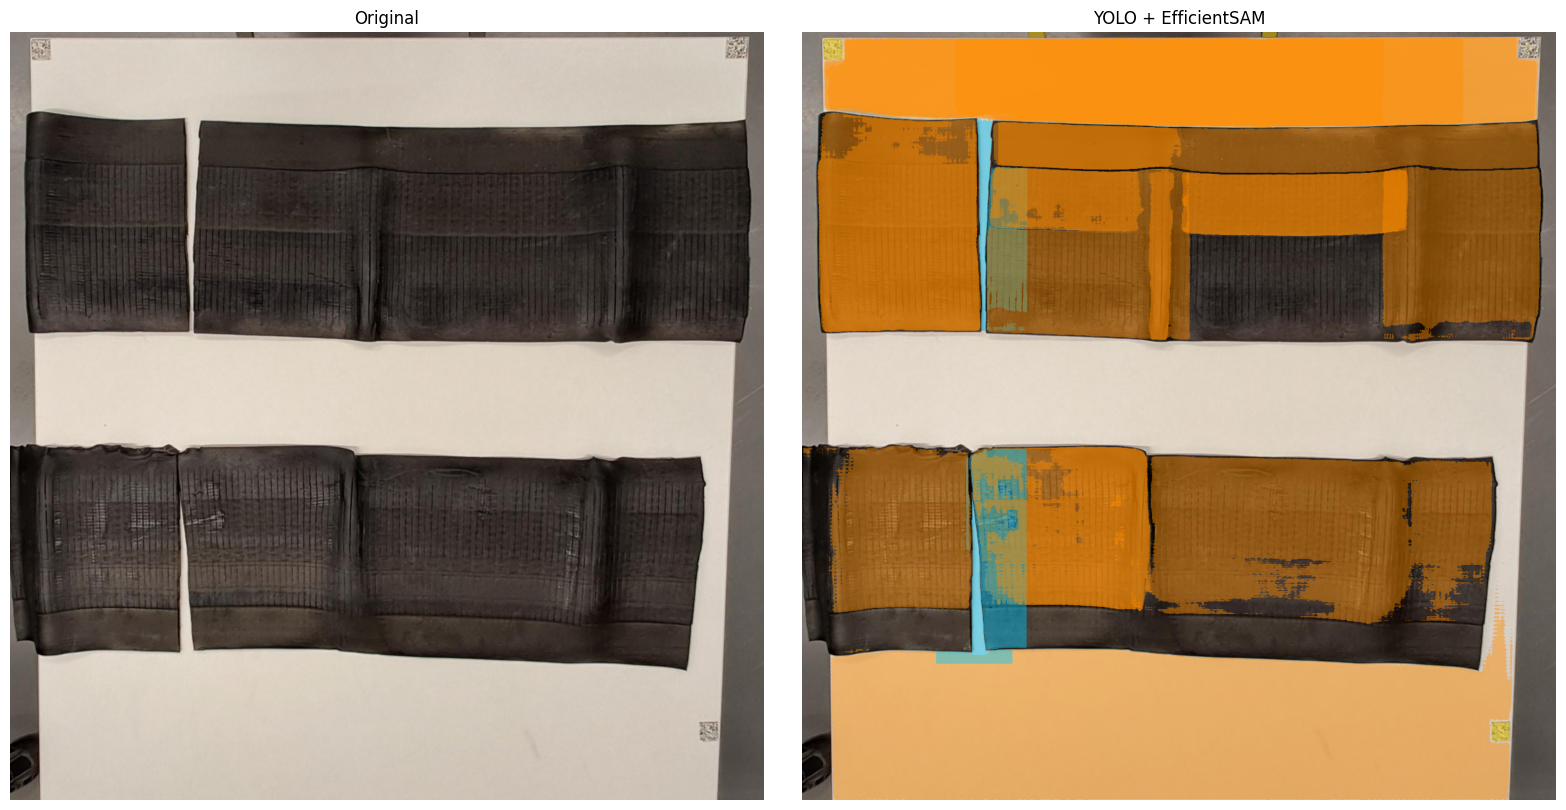

IoU por detección:
  rubber_strip: 0.015
  rubber_strip: 0.134
  rubber_strip: 0.095
  qr_code: 0.766
  qr_code: 0.014
  qr_code: 0.740
  rubber_strip: 0.582
  rubber_strip: 0.537
  cut_edge: 0.433
  rubber_strip: 0.675
  rubber_strip: 0.621
  cut_edge: 0.178
  rubber_strip: 0.818
  rubber_strip: 0.402
  rubber_strip: 0.519
  cut_edge: 0.698
  cut_edge: 0.104
  qr_code: 0.557
  rubber_strip: 0.072
  rubber_strip: 0.048
  rubber_strip: 0.058
  rubber_strip: 0.291
  qr_code: 0.448
  rubber_strip: 0.781
  rubber_strip: 0.645
  rubber_strip: 0.348
  rubber_strip: 0.158
  rubber_strip: 0.157


In [15]:
IMAGE_PATH = "../data/raw/multimedia_01.jpg"

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

# YOLOv9 → bboxes
preds = yolo(img_bgr, verbose=False)[0]

# Colores por clase
COLORS = {0: (0, 200, 255), 1: (255, 220, 0), 2: (255, 140, 0)}
ALPHA  = 0.45

overlay = img_rgb.copy().astype(np.float32)
iou_scores = []

for box in preds.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls  = int(box.cls[0])
    conf = float(box.conf[0])
    col  = COLORS.get(cls, (255, 255, 255))

    # EfficientSAM
    mask = run_efficient_sam(sam, img_rgb, [x1, y1, x2, y2])
    iou  = compute_iou(mask, [x1, y1, x2, y2], img_rgb.shape)
    iou_scores.append((CLASS_NAMES[cls], iou))

    # Pintar máscara en overlay
    colored = np.zeros_like(overlay)
    colored[mask] = col
    overlay = np.where(mask[:, :, None], overlay * (1 - ALPHA) + colored * ALPHA, overlay)

    # Bbox + label
    cv2.rectangle(overlay.astype(np.uint8), (x1, y1), (x2, y2), col, 2)
    cv2.putText(overlay.astype(np.uint8),
                f"{CLASS_NAMES[cls]} {conf:.2f} IoU:{iou:.2f}",
                (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(img_rgb);             axes[0].set_title("Original");     axes[0].axis('off')
axes[1].imshow(overlay.astype(np.uint8)); axes[1].set_title("YOLO + EfficientSAM"); axes[1].axis('off')
plt.tight_layout()
plt.show()

print("IoU por detección:")
for name, iou in iou_scores:
    print(f"  {name}: {iou:.3f}")

## 5. Evaluación IoU sobre todo el dataset

In [ ]:
from collections import defaultdict

image_paths = sorted(Path("../data/raw").glob("*.jpg"))
print(f"Imágenes: {len(image_paths)}")

iou_per_class = defaultdict(list)

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    preds = yolo(img_bgr, verbose=False)[0]

    for box in preds.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        try:
            mask = run_efficient_sam(sam, img_rgb, [x1, y1, x2, y2])
            iou  = compute_iou(mask, [x1, y1, x2, y2], img_rgb.shape)
            iou_per_class[CLASS_NAMES[cls]].append(iou)
        except Exception as e:
            print(f"  [WARN] {img_path.name} cls={cls}: {e}")

print("\nIoU medio por clase:")
for cls_name, ious in sorted(iou_per_class.items()):
    print(f"  {cls_name}: {np.mean(ious):.3f}  (n={len(ious)})")